# EuroSAT Multispectral Feature Engineering Pipeline

This notebook prepares the **EuroSAT multispectral (MS)** dataset for land-use classification.  
the full pipeline: data loading → spectral index computation → normalization → correlation-based feature selection → data augmentation.

**Dataset:** EuroSAT MS, 13-band Sentinel-2 satellite imagery across 10 land-use classes  
**Output files:** `images_aug.npy`, `images_selected.npy`, `labels_enc.npy`, `label_classes.npy`, `feature_names.npy`, `scaler.pkl`

In [ ]:
import os
import rasterio
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Loading

Iterates over each class folder inside the dataset root path and reads every image
Each image is stored as a NumPy array of shape `(C, H, W)` and its folder name is recorded as the label

In [ ]:
path = r"D:\.COMPUTER SCIENCE\.DEPI\Graduation Project\EuroSAT_MS"

images, labels = [], []

for folder in sorted(os.listdir(path)):
    folder_path = os.path.join(path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        with rasterio.open(img_path) as src:
            img = src.read()

        images.append(img)
        labels.append(folder)
     
images = np.array(images, dtype=np.float32) 
labels = np.array(labels)
classes = sorted(set(labels))     

## 3. Stratified Subsampling

**30% of the dataset** was retained using `StratifiedShuffleSplit` which ensures every class keeps its original proportion in the sampled subset.

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.70, random_state=42)
keep_idx, _ = next(sss.split(images, labels))

images = images[keep_idx]
labels = labels[keep_idx]

In [3]:
print(f"Dataset shape  : {images.shape}")
print(f"Classes ({len(classes)}): {classes}")

Dataset shape  : (8100, 13, 64, 64)
Classes (10): [np.str_('AnnualCrop'), np.str_('Forest'), np.str_('HerbaceousVegetation'), np.str_('Highway'), np.str_('Industrial'), np.str_('Pasture'), np.str_('PermanentCrop'), np.str_('Residential'), np.str_('River'), np.str_('SeaLake')]


## 4. Band Index Mapping

Sentinel-2 MS images have 13 bands (B00–B12). only 6 were used in this notebook 

| Variable | Band | Sentinel-2 Name |
|----------|------|-----------------|
| `B_BLUE`  | 1  | B02 - Blue      |
| `B_GREEN` | 2  | B03 - Green     |
| `B_RED`   | 3  | B04 - Red       |
| `B_NIR`   | 7  | B08 - Near Infrared |
| `B_SWIR1` | 11 | B11 - Short-Wave Infrared 1 |
| `B_SWIR2` | 12 | B12 - Short-Wave Infrared 2 |

In [ ]:
B_BLUE  = 1
B_GREEN = 2
B_RED   = 3
B_NIR   = 7
B_SWIR1 = 11
B_SWIR2 = 12

## 5. Helper Functions

- **`get_rgb(img)`** - extracts a visual RGB preview by pulling bands R/G/B, then applies 2nd–98th percentile contrast stretching so the image looks natural
- **`safe_norm(a, b)`** - computes a normalized difference `(a - b) / (a + b + ε)`, with a small epsilon to prevent division by zero. Used by all spectral indices below

In [65]:
def get_rgb(img):
    rgb = img[[B_RED, B_GREEN, B_BLUE]].astype(np.float32).transpose(1, 2, 0)
    p2, p98 = np.percentile(rgb, (2, 98))
    if p98 - p2 < 1e-3:
        return np.clip(rgb, 0, 1)
    
    rgb_stretched = (rgb - p2) / (p98 - p2 + 1e-6)
    
    return np.clip(rgb_stretched, 0, 1)

In [6]:
def safe_norm(a, b, eps=1e-8):
    return (a - b) / (a + b + eps)

## 6. Spectral Index Computation (`compute_indices`)

Four vegetation and land-cover indices are computed per image and concatenated as extra channels:

| Index  | Formula | Detects |
|--------|----------|---------|
| **NDVI** | (NIR − R) / (NIR + R) | Vegetation density |
| **GNDVI** | (NIR − G) / (NIR + G) | Chlorophyll / green vegetation |
| **NDWI** | (G − NIR) / (G + NIR) | Open water bodies |
| **NDBI** | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up / urban areas |

All indices are clipped to `[-1, 1]`. The output tensor per image has shape `(13 original bands + 4 indices, H, W)`.

In [ ]:
def compute_indices(img):
    R = img[B_RED].astype(np.float32)
    G = img[B_GREEN].astype(np.float32)
    B = img[B_BLUE].astype(np.float32)
    NIR = img[B_NIR].astype(np.float32)
    SW1 = img[B_SWIR1].astype(np.float32)
    SW2 = img[B_SWIR2].astype(np.float32)

    NDVI = safe_norm(NIR, R)
    GNDVI = safe_norm(NIR, G)
    NDWI = safe_norm(G, NIR)
    NDBI = safe_norm(SW1, NIR)

    indices = np.stack([
        np.clip(NDVI, -1, 1),
        np.clip(GNDVI, -1, 1),
        np.clip(NDWI, -1, 1),
        np.clip(NDBI, -1, 1)
    ], axis=0)
    
    stacked_img = np.concatenate([img, indices], axis=0)

    return stacked_img

images_fe = np.array([compute_indices(img) for img in images])
print(f"Feature shape after indices: {images_fe.shape}")

## 7. Label Encoding

Class name strings (e.g. `"Forest"`, `"Highway"`) are converted to integer labels using `sklearn.LabelEncoder`.  
The mapping is stored in `le.classes_` and saved later as `label_classes.npy` so it can be decoded at inference time

In [ ]:
le = LabelEncoder()
labels_enc = le.fit_transform(labels)  
print("Classes:", list(le.classes_))

## 8. Per-Feature Min-Max Normalization

Each of the 17 feature channels (13 bands + 4 indices) is independently scaled to `[0, 1]` using `MinMaxScaler`.

In [9]:
N, C, H, W = images_fe.shape

flat = images_fe.transpose(0, 2, 3, 1).reshape(-1, C)   

scaler = MinMaxScaler()

images_norm = scaler.fit_transform(flat).reshape(N, H, W, C).transpose(0, 3, 1, 2)

print(f"Min: {images_norm.min():.4f}, Max: {images_norm.max():.4f}")  

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

np.save("images_norm.npy", images_norm) 

Min: 0.0000, Max: 1.0000


## 9. Correlation Analysis & Feature Selection

To remove redundant features, three filtering steps are applied:

1. Each image is **mean-pooled** spatially `(H, W) → scalar` per channel, producing a flat `(N, 17)` feature matrix
2. A **Pearson correlation matrix** is computed and visualized as a heatmap.
3. **Variance threshold** (`< 0.0015`) - drops near-constant channels that carry no signal across images
4. **F-score ranking** (`f_classif`) - for each correlated pair, the feature that separates classes less effectively is dropped
5. **Correlation threshold** (`|correlation| > 0.98`) - any remaining highly correlated pair triggers removal of the less informative one.

Final kept features are printed with their variance and F-score

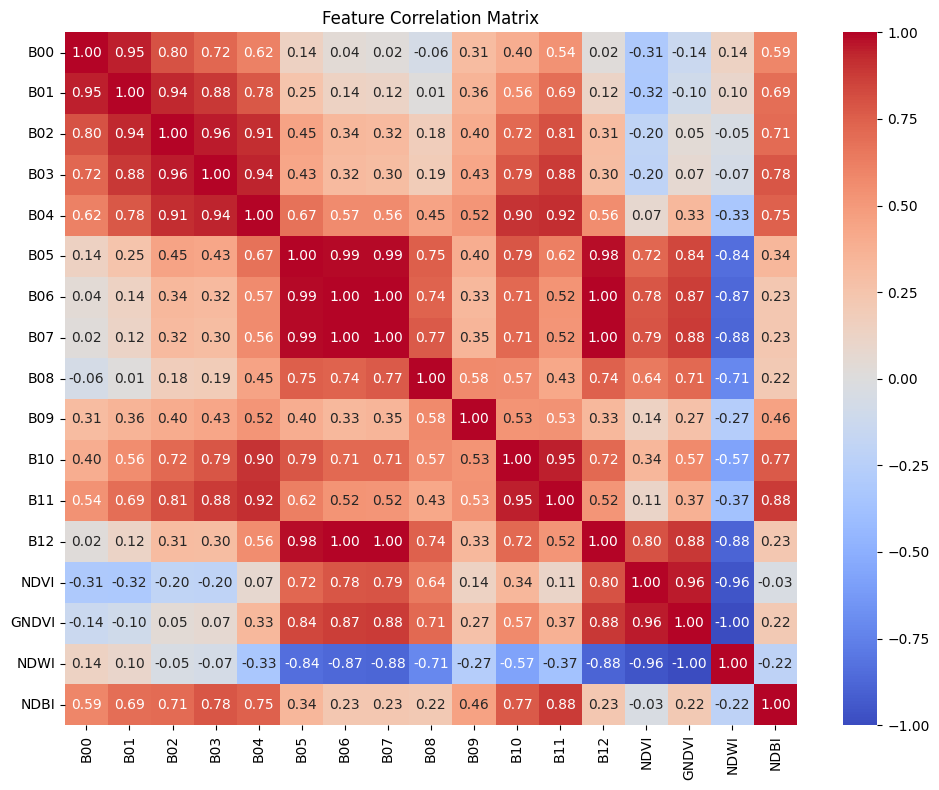

Low variance features dropped: ['B00', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B09', 'B11']
Drop B06 - corr: 0.99, f_scores: B05=2416.3, B06=2311.0
Drop B07 - corr: 0.99, f_scores: B05=2416.3, B07=2388.1
Drop B05 - corr: 0.98, f_scores: B05=2416.3, B12=2561.6
Drop B06 - corr: 1.00, f_scores: B06=2311.0, B07=2388.1
Drop B06 - corr: 1.00, f_scores: B06=2311.0, B12=2561.6
Drop B07 - corr: 1.00, f_scores: B07=2388.1, B12=2561.6
Drop GNDVI - corr: -1.00, f_scores: GNDVI=5814.7, NDWI=5815.0

Keeping 6/17:
  B08 - variance: 0.00430, f_score: 909.8
  B10 - variance: 0.00156, f_score: 2157.9
  B12 - variance: 0.00156, f_score: 2561.6
  NDVI - variance: 0.02174, f_score: 3285.4
  NDWI - variance: 0.02384, f_score: 5815.0
  NDBI - variance: 0.01387, f_score: 2020.2


In [36]:
from sklearn.feature_selection import VarianceThreshold, f_classif

feature_names = [f"B{i:02d}" for i in range(13)] + ["NDVI", "GNDVI", "NDWI", "NDBI"]
X = images_norm.mean(axis=(2, 3))

# Correlation heatmap
df = pd.DataFrame(X, columns=feature_names)
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=feature_names, yticklabels=feature_names)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Variance threshold
selector = VarianceThreshold(threshold=0.0015)
selector.fit(X)
low_var = [feature_names[i] for i, v in enumerate(selector.variances_) if v < 0.0015]
print(f"Low variance features dropped: {low_var}")

# F-scores
f_scores, _ = f_classif(X, labels_enc)
f_score_map = dict(zip(feature_names, f_scores))

to_drop = set()
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.98:
            fi, fj = feature_names[i], feature_names[j]
            worse = fi if f_score_map[fi] < f_score_map[fj] else fj
            to_drop.add(worse)
            print(f"Drop {worse} - corr: {corr.iloc[i,j]:.2f}, f_scores: {fi}={f_score_map[fi]:.1f}, {fj}={f_score_map[fj]:.1f}")

to_drop.update(low_var)
keep = [f for f in feature_names if f not in to_drop]
print(f"\nKeeping {len(keep)}/17:")
for k in keep:
    idx = feature_names.index(k)
    print(f"  {k} - variance: {selector.variances_[idx]:.5f}, f_score: {f_score_map[k]:.1f}")

keep_idx = [feature_names.index(f) for f in keep]
images_selected = images_norm[:, keep_idx, :, :]

## 10. Data Augmentation

`albumentations` wa used to apply stochastic spatial and photometric transforms during preprocessing.  
All transforms operate on `(H, W, C)` format, so images are transposed before and after.

| Transform | Probability |
|-----------|-------------|
| `RandomResizedCrop(64×64)` | 1.0 |
| `RandomRotate90` | 0.75 |
| `HorizontalFlip` | 0.65 |
| `VerticalFlip` | 0.30 |
| `Transpose` | 0.30 |
| `RandomBrightnessContrast` | 0.30 |
| `GridDistortion` | 0.20 |
| `GaussianBlur` | 0.15 |

In [71]:
import albumentations as A
import numpy as np

data_augmentation = A.Compose([
        A.RandomResizedCrop(size=(64, 64), scale=(0.75, 1.0), p=1.0),
        A.RandomRotate90(p=0.75),
        A.HorizontalFlip(p=0.65),
        A.VerticalFlip(p=0.3),
        A.Transpose(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15,
                               contrast_limit=0.15, p=0.3),
        A.GridDistortion(num_steps=4, distort_limit=0.2, p=0.2),
        A.GaussianBlur(blur_limit=(3, 5), p=0.15)
])

def augment(img):
    img_hwc = (img.transpose(1, 2, 0) * 255).clip(0, 255).astype(np.uint8)
    augmented = data_augmentation(image=img_hwc)["image"]
    return augmented.astype(np.float32).transpose(2, 0, 1) / 255.0

Augmented shape: (8100, 6, 64, 64)


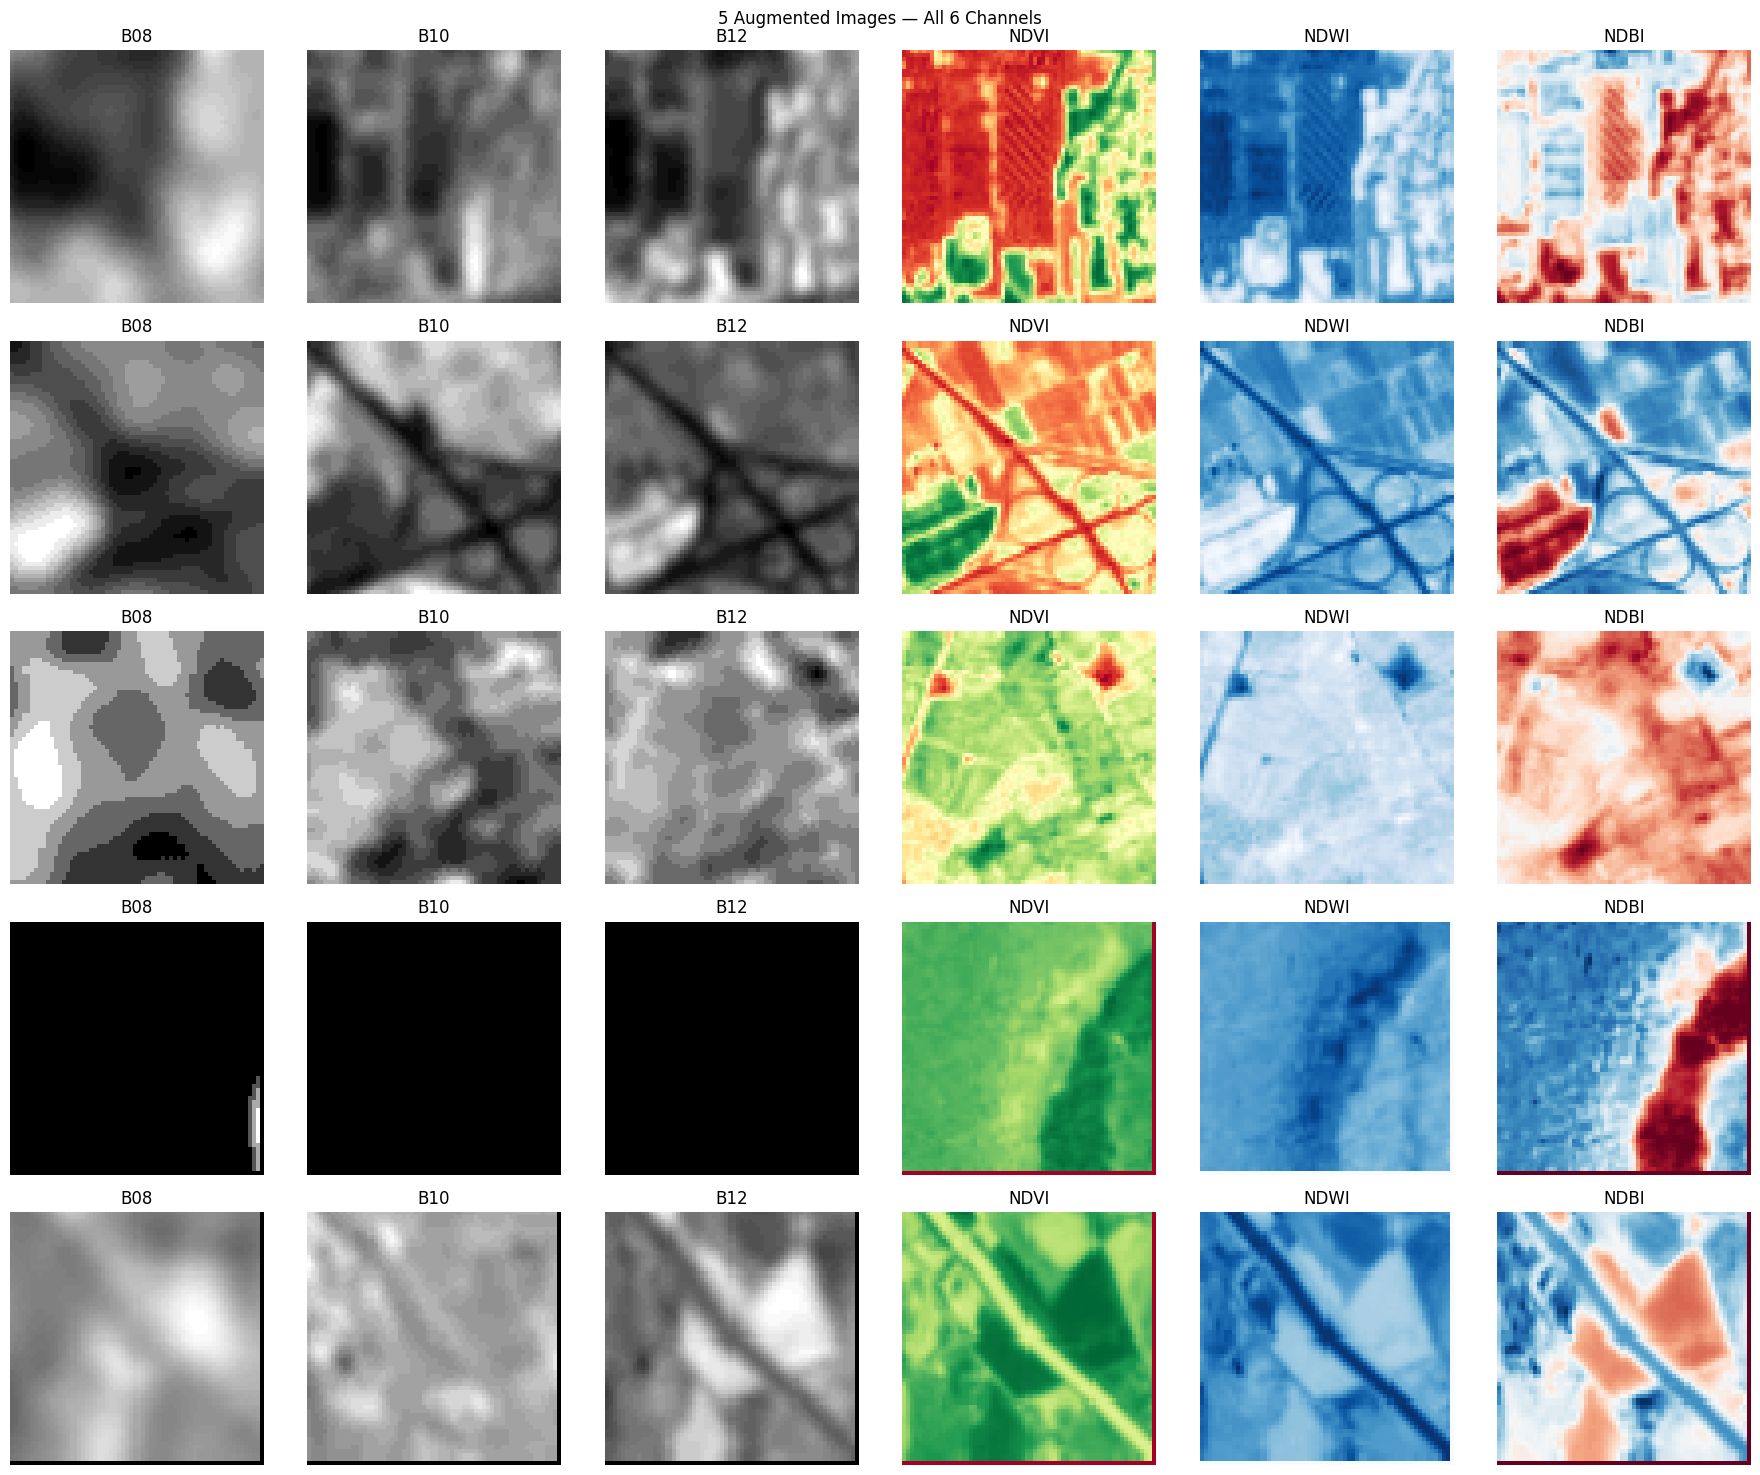

In [78]:
channel_names = ["B08", "B10", "B12", "NDVI", "NDWI", "NDBI"]
cmaps = ["gray", "gray", "gray", "RdYlGn", "Blues", "RdBu"]

images_aug = np.array([augment(img) for img in images_selected])
print(f"Augmented shape: {images_aug.shape}")

fig, axes = plt.subplots(5, 6, figsize=(18, 15))
for row in range(5):
    for col in range(6):
        axes[row, col].imshow(images_aug[row, col], cmap=cmaps[col])
        axes[row, col].set_title(channel_names[col])
        axes[row, col].axis("off")
plt.suptitle("5 Augmented Images — All 6 Channels")
plt.tight_layout()
plt.show()

## 11. Save All Outputs

The following files are written to disk for use in the modeling notebook:

| File | Contents |
|------|----------|
| `images_aug.npy` | Augmented, selected, normalized images - shape `(N, C_selected, 64, 64)` |
| `images_selected.npy` | Pre-augmentation selected images |
| `labels_enc.npy` | Integer-encoded labels |
| `label_classes.npy` | Class name strings (for decoding predictions) |
| `feature_names.npy` | Names of the kept feature channels |
| `scaler.pkl` | Fitted `MinMaxScaler` (required for inference preprocessing) |

In [ ]:
save_dir = r"D:\.COMPUTER SCIENCE\.DEPI\Graduation Project\processed_data"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "images_aug.npy"),      images_aug)
np.save(os.path.join(save_dir, "images_selected.npy"), images_selected)
np.save(os.path.join(save_dir, "labels_enc.npy"),      labels_enc)
np.save(os.path.join(save_dir, "label_classes.npy"),   le.classes_)
np.save(os.path.join(save_dir, "feature_names.npy"),   np.array(keep))

with open(os.path.join(save_dir, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(save_dir, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)    

print(f"All files saved to: {save_dir}")

All files saved to: D:\.COMPUTER SCIENCE\.DEPI\Graduation Project\processed_data
